In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [43]:
# Load Dataset
df = pd.read_csv("../input/fertilizer_recommendation.csv") 
df

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Silt,7.10,26.37,0.76,0.66,89,20,69,22.07,42.75,1857.78,Maize,Sowing,Kharif,Drip,Sugarcane,West,57.12,6.81,DAP
9996,Clay,5.21,46.35,0.80,1.03,40,28,99,16.40,41.74,858.69,Tomato,Harvest,Zaid,Drip,Maize,West,85.12,1.25,Urea
9997,Loamy,4.70,56.16,0.89,1.12,51,71,61,27.01,44.82,544.08,Tomato,Harvest,Rabi,Canal,Cotton,East,218.88,1.74,Urea
9998,Loamy,7.23,41.86,1.46,0.93,152,81,94,24.64,43.27,1510.97,Sugarcane,Vegetative,Rabi,Drip,Rice,West,240.37,3.70,NPK


In [44]:
# Clean column names (convert to lowercase)
df.columns = df.columns.str.lower()
df

,soil_type,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,nitrogen_level,phosphorus_level,potassium_level,temperature,humidity,rainfall,crop_type,crop_growth_stage,season,irrigation_type,previous_crop,region,fertilizer_used_last_season,yield_last_season,recommended_fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Silt,7.10,26.37,0.76,0.66,89,20,69,22.07,42.75,1857.78,Maize,Sowing,Kharif,Drip,Sugarcane,West,57.12,6.81,DAP
9996,Clay,5.21,46.35,0.80,1.03,40,28,99,16.40,41.74,858.69,Tomato,Harvest,Zaid,Drip,Maize,West,85.12,1.25,Urea
9997,Loamy,4.70,56.16,0.89,1.12,51,71,61,27.01,44.82,544.08,Tomato,Harvest,Rabi,Canal,Cotton,East,218.88,1.74,Urea
9998,Loamy,7.23,41.86,1.46,0.93,152,81,94,24.64,43.27,1510.97,Sugarcane,Vegetative,Rabi,Drip,Rice,West,240.37,3.70,NPK


In [45]:
# Summary statistics for numerical features
df.describe(percentiles=[0.25, 0.5, 0.75])
df.describe()

,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,nitrogen_level,phosphorus_level,potassium_level,temperature,humidity,rainfall,fertilizer_used_last_season,yield_last_season
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.485728,35.411531,0.844731,1.543156,88.995000,48.965100,64.147000,25.058906,60.093727,1588.085798,176.165508,4.531666
std,1.152964,14.413002,0.372406,0.839514,40.336674,23.195588,31.867211,8.601550,17.386120,810.992404,72.235790,2.013522
min,4.500000,10.000000,0.200000,0.100000,20.000000,10.000000,10.000000,10.000000,30.010000,200.080000,50.010000,1.000000
25%,5.490000,23.030000,0.520000,0.820000,54.000000,29.000000,37.000000,17.580000,44.925000,874.780000,113.175000,2.780000
50%,6.460000,35.645000,0.850000,1.530000,89.000000,49.000000,64.000000,25.085000,60.345000,1594.295000,176.835000,4.550000
75%,7.490000,47.662500,1.160000,2.270000,124.000000,69.000000,92.000000,32.502500,75.420000,2283.782500,239.232500,6.260000
max,8.500000,60.000000,1.500000,3.000000,159.000000,89.000000,119.000000,40.000000,89.990000,2999.980000,300.000000,8.000000


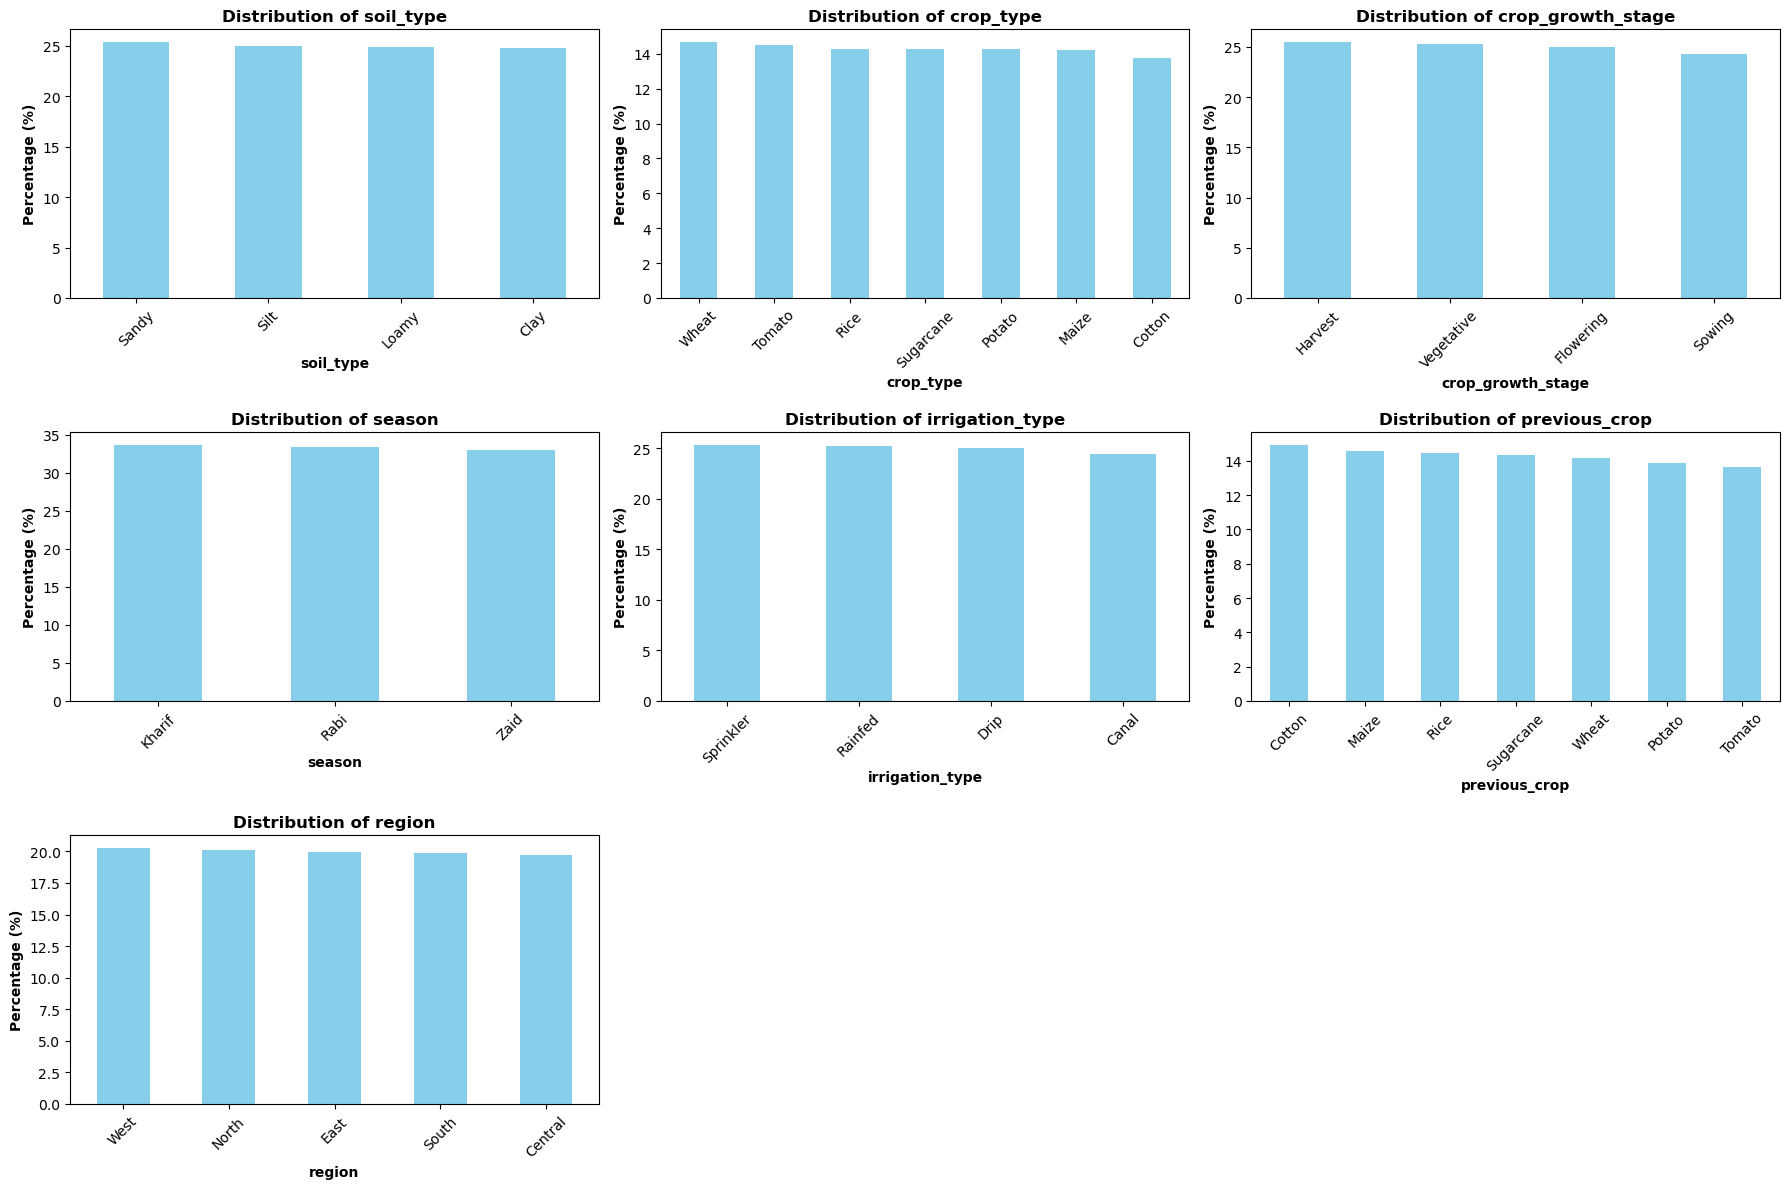

In [46]:
# Categorical columns
categorical = ['soil_type', 'crop_type', 'crop_growth_stage', 'season', 'irrigation_type', 'previous_crop', 'region']

# Plot percentage distribution of categorical variables
rows = 3
cols = 3

plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical, 1):
    plt.subplot(rows, cols, i)
    
    # Percentage distribution
    freq = df[col].value_counts(normalize=True) * 100
    
    freq.plot(kind='bar', color='skyblue')
    
    plt.title(f"Distribution of {col}", fontweight='bold')
    plt.ylabel("Percentage (%)", fontweight='bold')
    plt.xlabel(col, fontweight='bold')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()

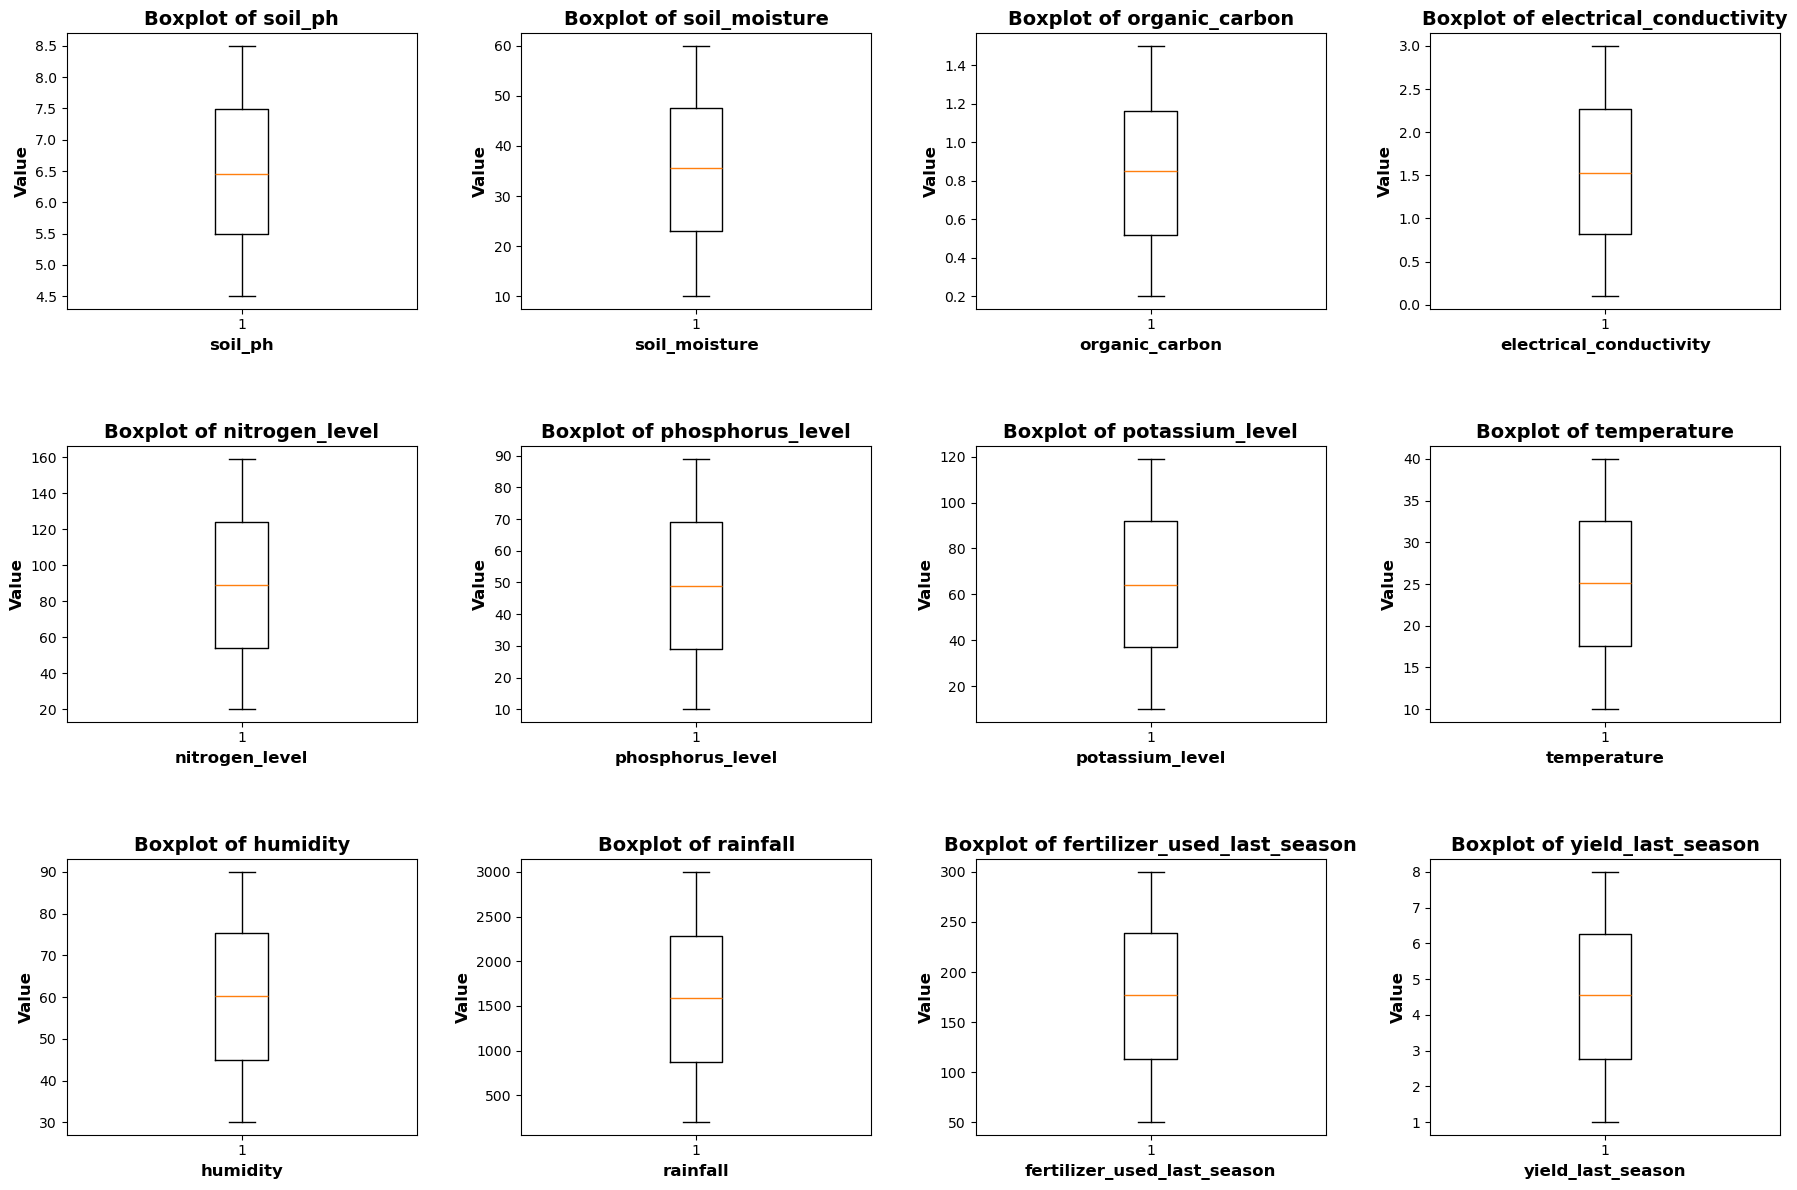

In [47]:
# Numerical columns (excluding target)

numerical_var = df.drop("recommended_fertilizer", axis=1)
numerical = [col for col in numerical_var.columns if col not in categorical]
mumerical_df = df[numerical]

# Boxplots for numerical variables
num_cols = mumerical_df.columns

rows = 3
cols = 4

plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    plt.boxplot(mumerical_df[col], vert=True)
    
    plt.title(f"Boxplot of {col}", fontsize=14, fontweight='bold')
    plt.ylabel("Value", fontsize=12, fontweight='bold')
    plt.xlabel(col, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [48]:
# Target variable distribution

target_distr = df["recommended_fertilizer"].value_counts()
target_distr


recommended_fertilizer
Urea             3101
DAP              2920
MOP              1408
Compost           996
Zinc Sulphate     752
NPK               641
SSP               182
Name: count, dtype: int64

In [49]:
# Function: Boxplots of numerical variables grouped by a categorical feature
cat = categorical[1]

def create_boxplot(df, cat, num_values):

    cols = 4
    rows = 3

    plt.figure(figsize=(18, 15))

    for i, num in enumerate(num_values, 1): 
        groups = [(df[df[cat] == level][num]/df[num].max())*100 for level in df[cat].unique()]

        plt.subplot(rows, cols, i)
        plt.boxplot(groups, tick_labels = df[cat].unique())
        plt.title(f"{num} (%) by {cat}", fontsize=14, fontweight='bold')
        plt.xlabel(cat, fontsize=12, fontweight='bold')
        plt.ylabel(f"{num} (%)", fontsize=12, fontweight='bold')
        plt.xticks(rotation=45)
        
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    plt.show()

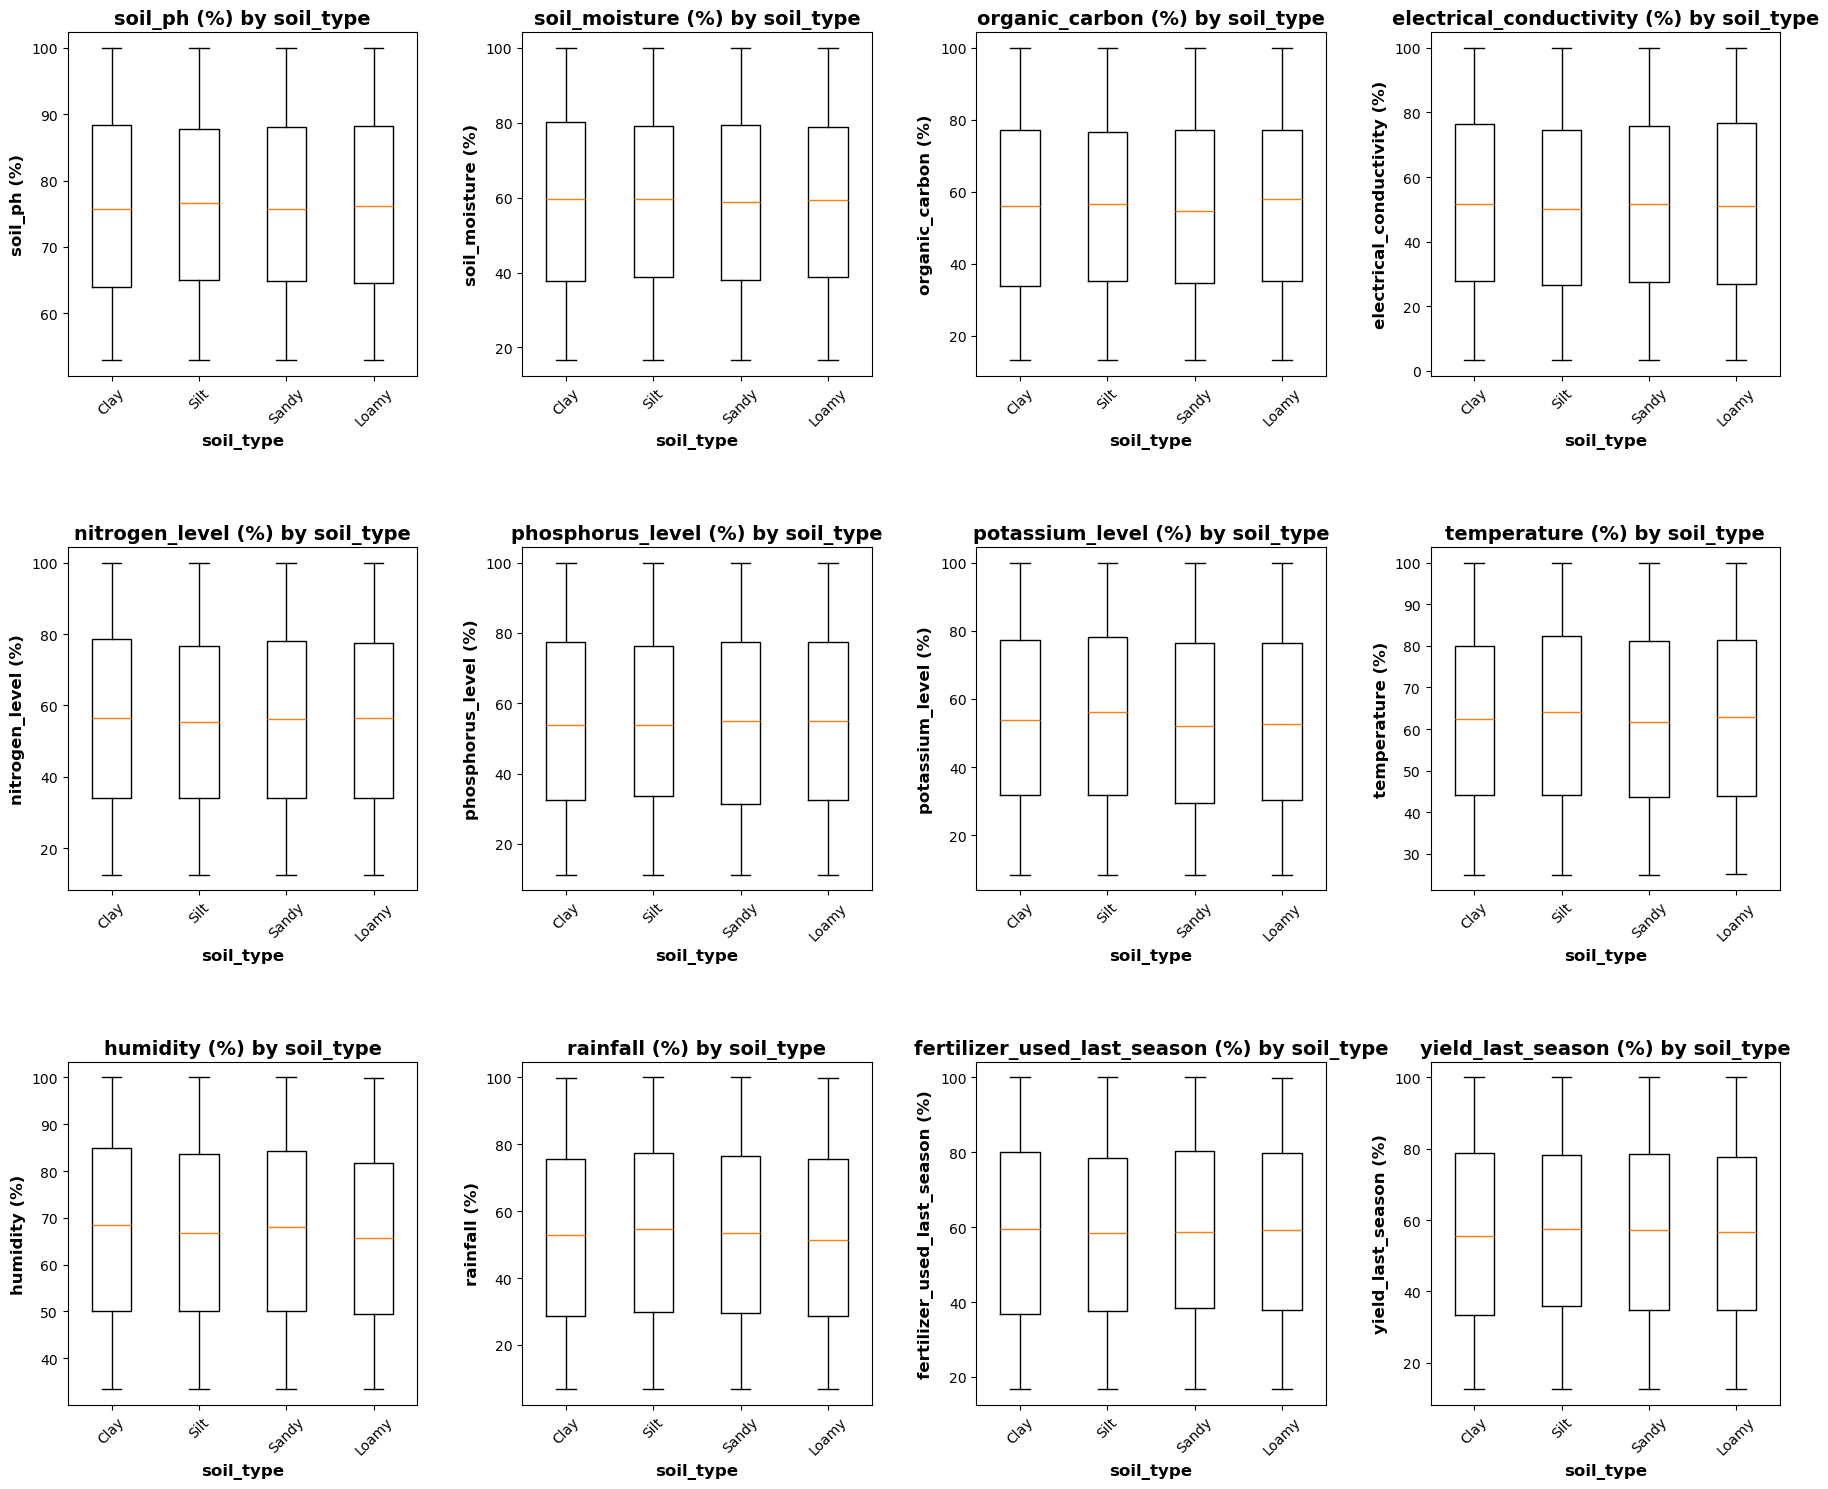

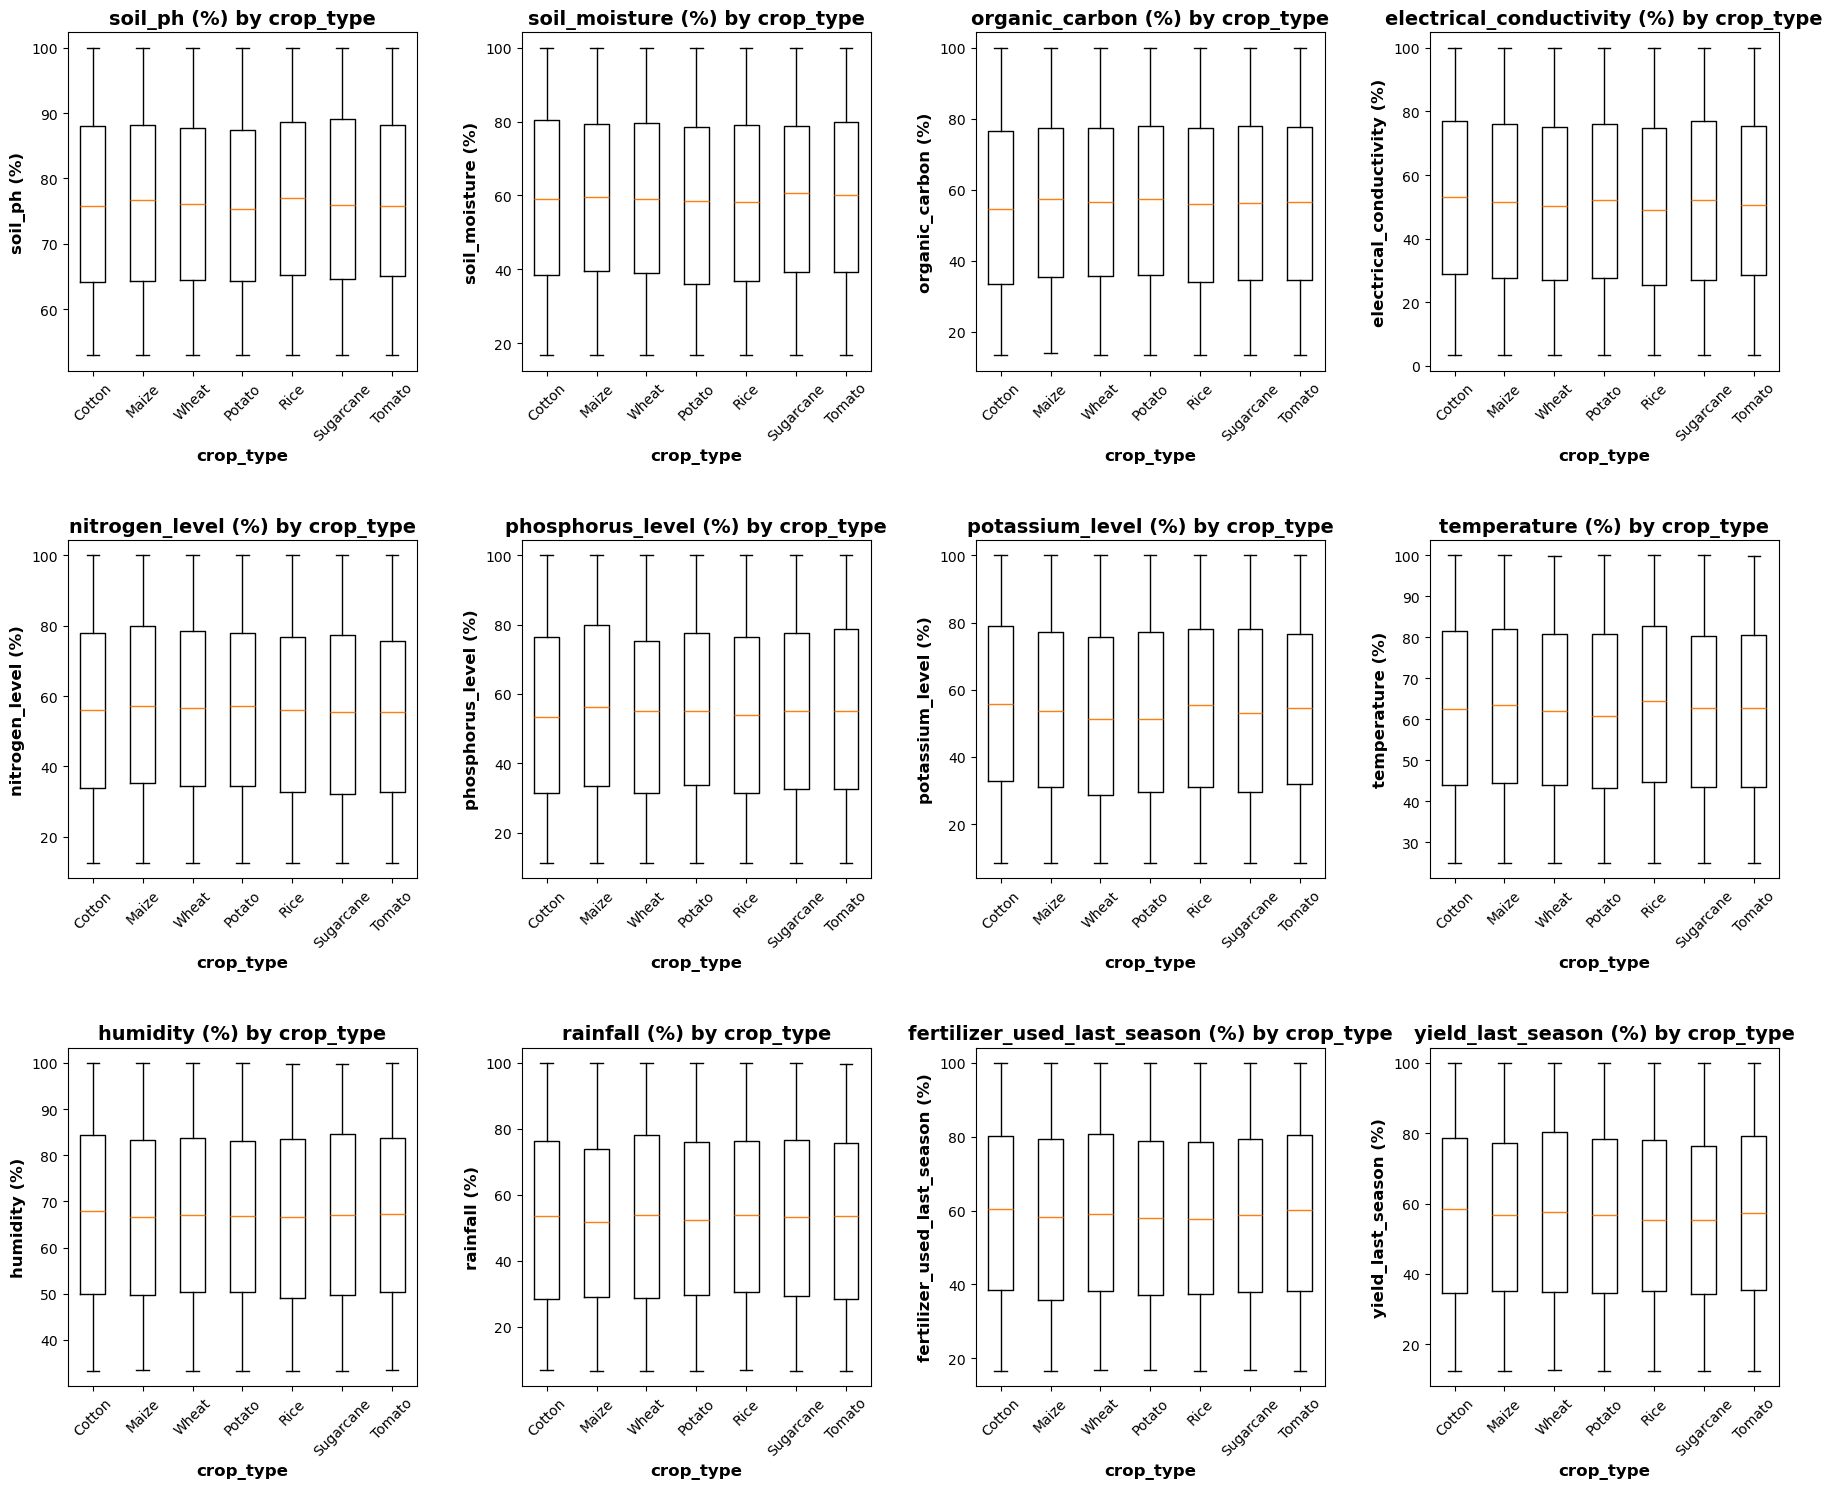

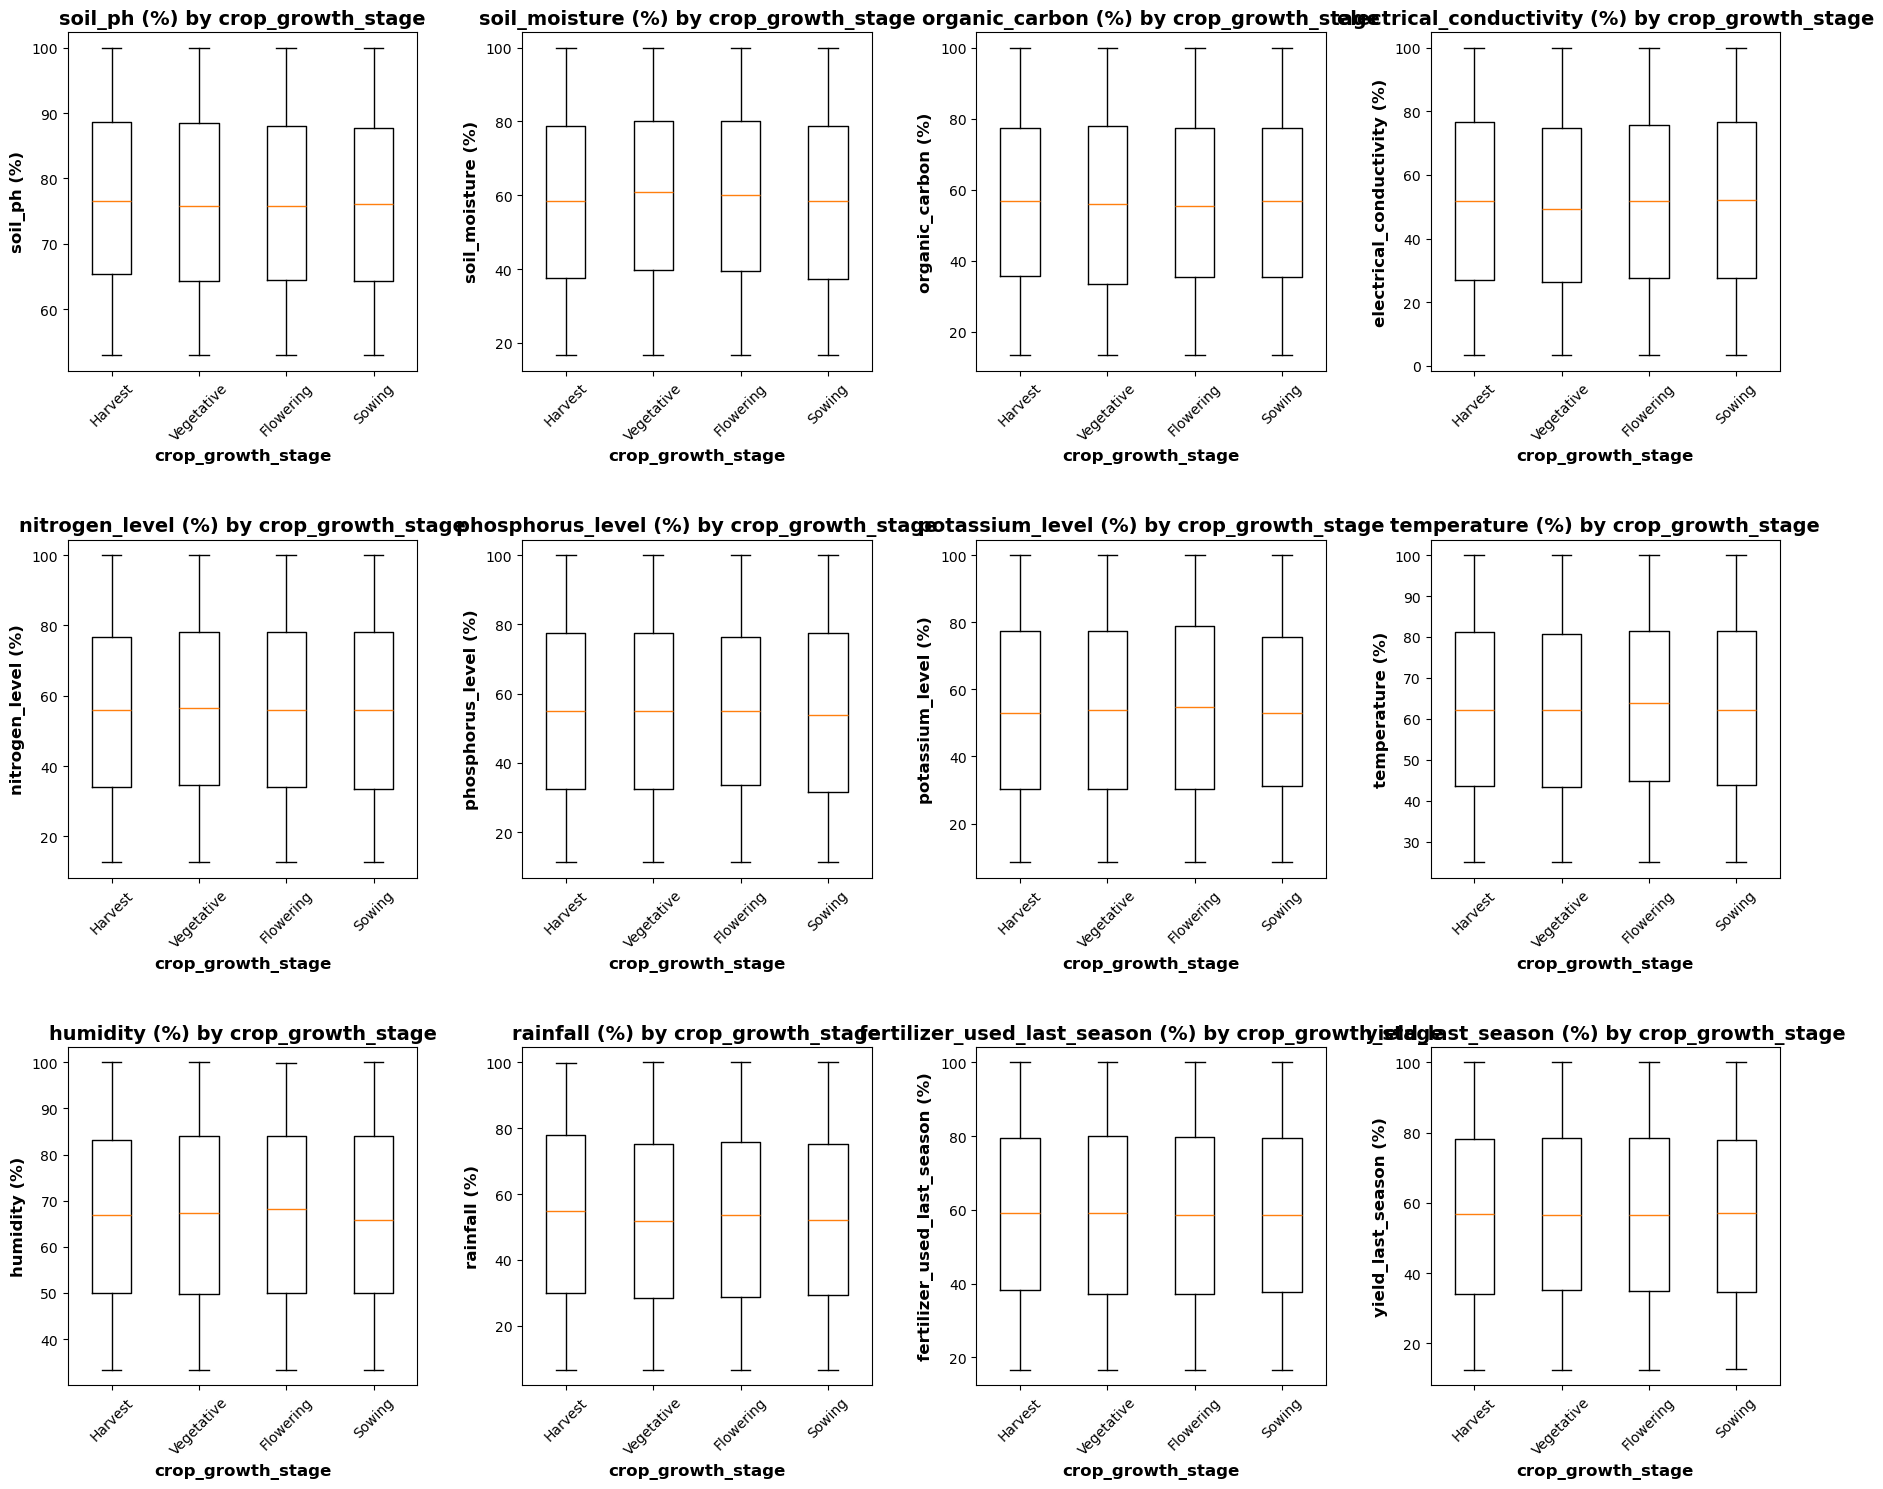

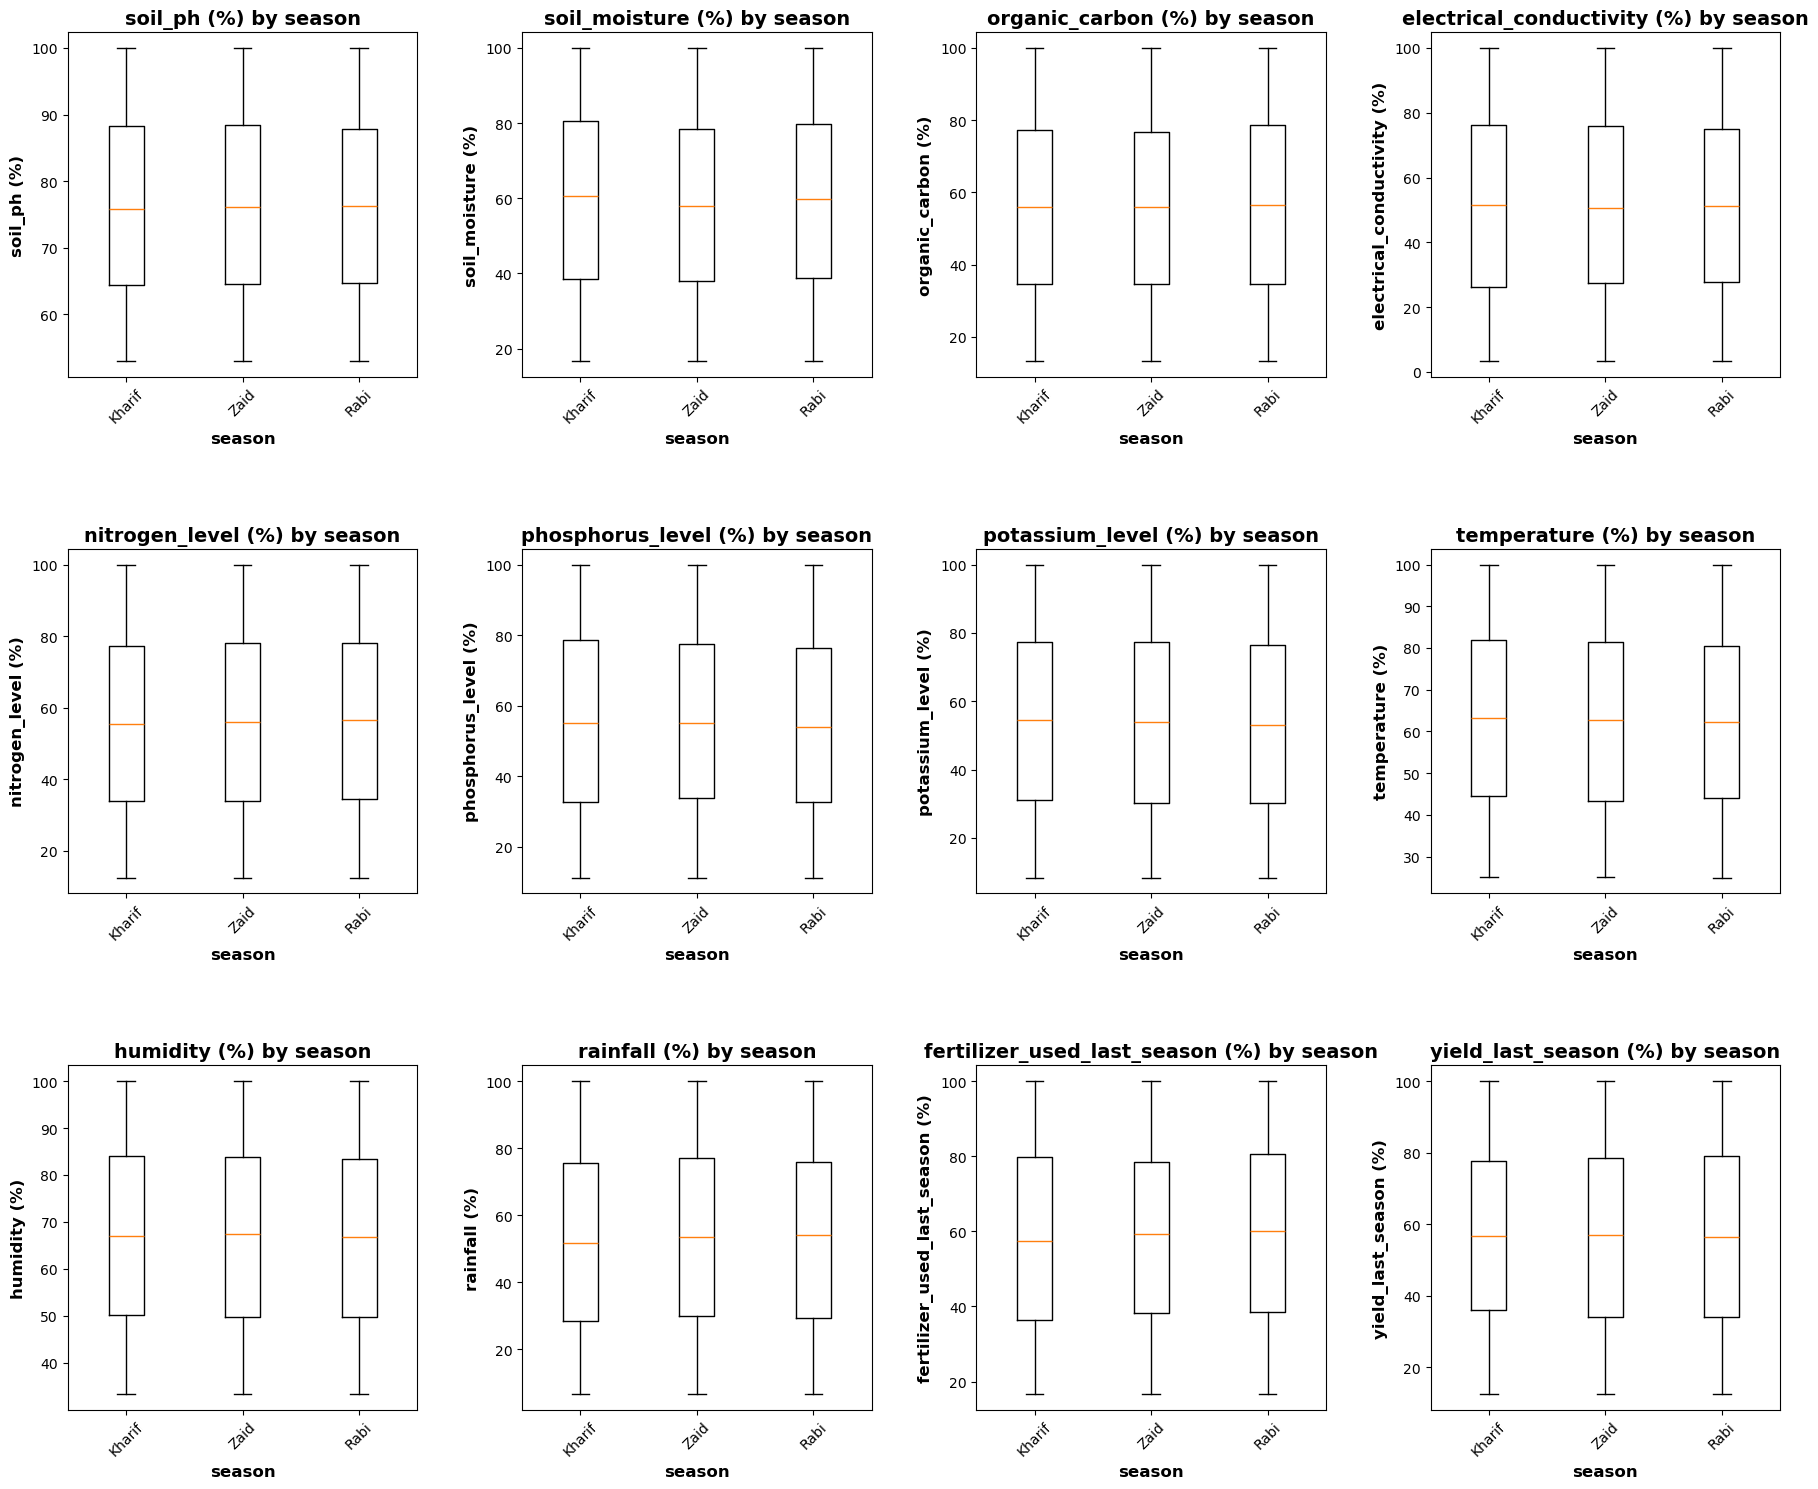

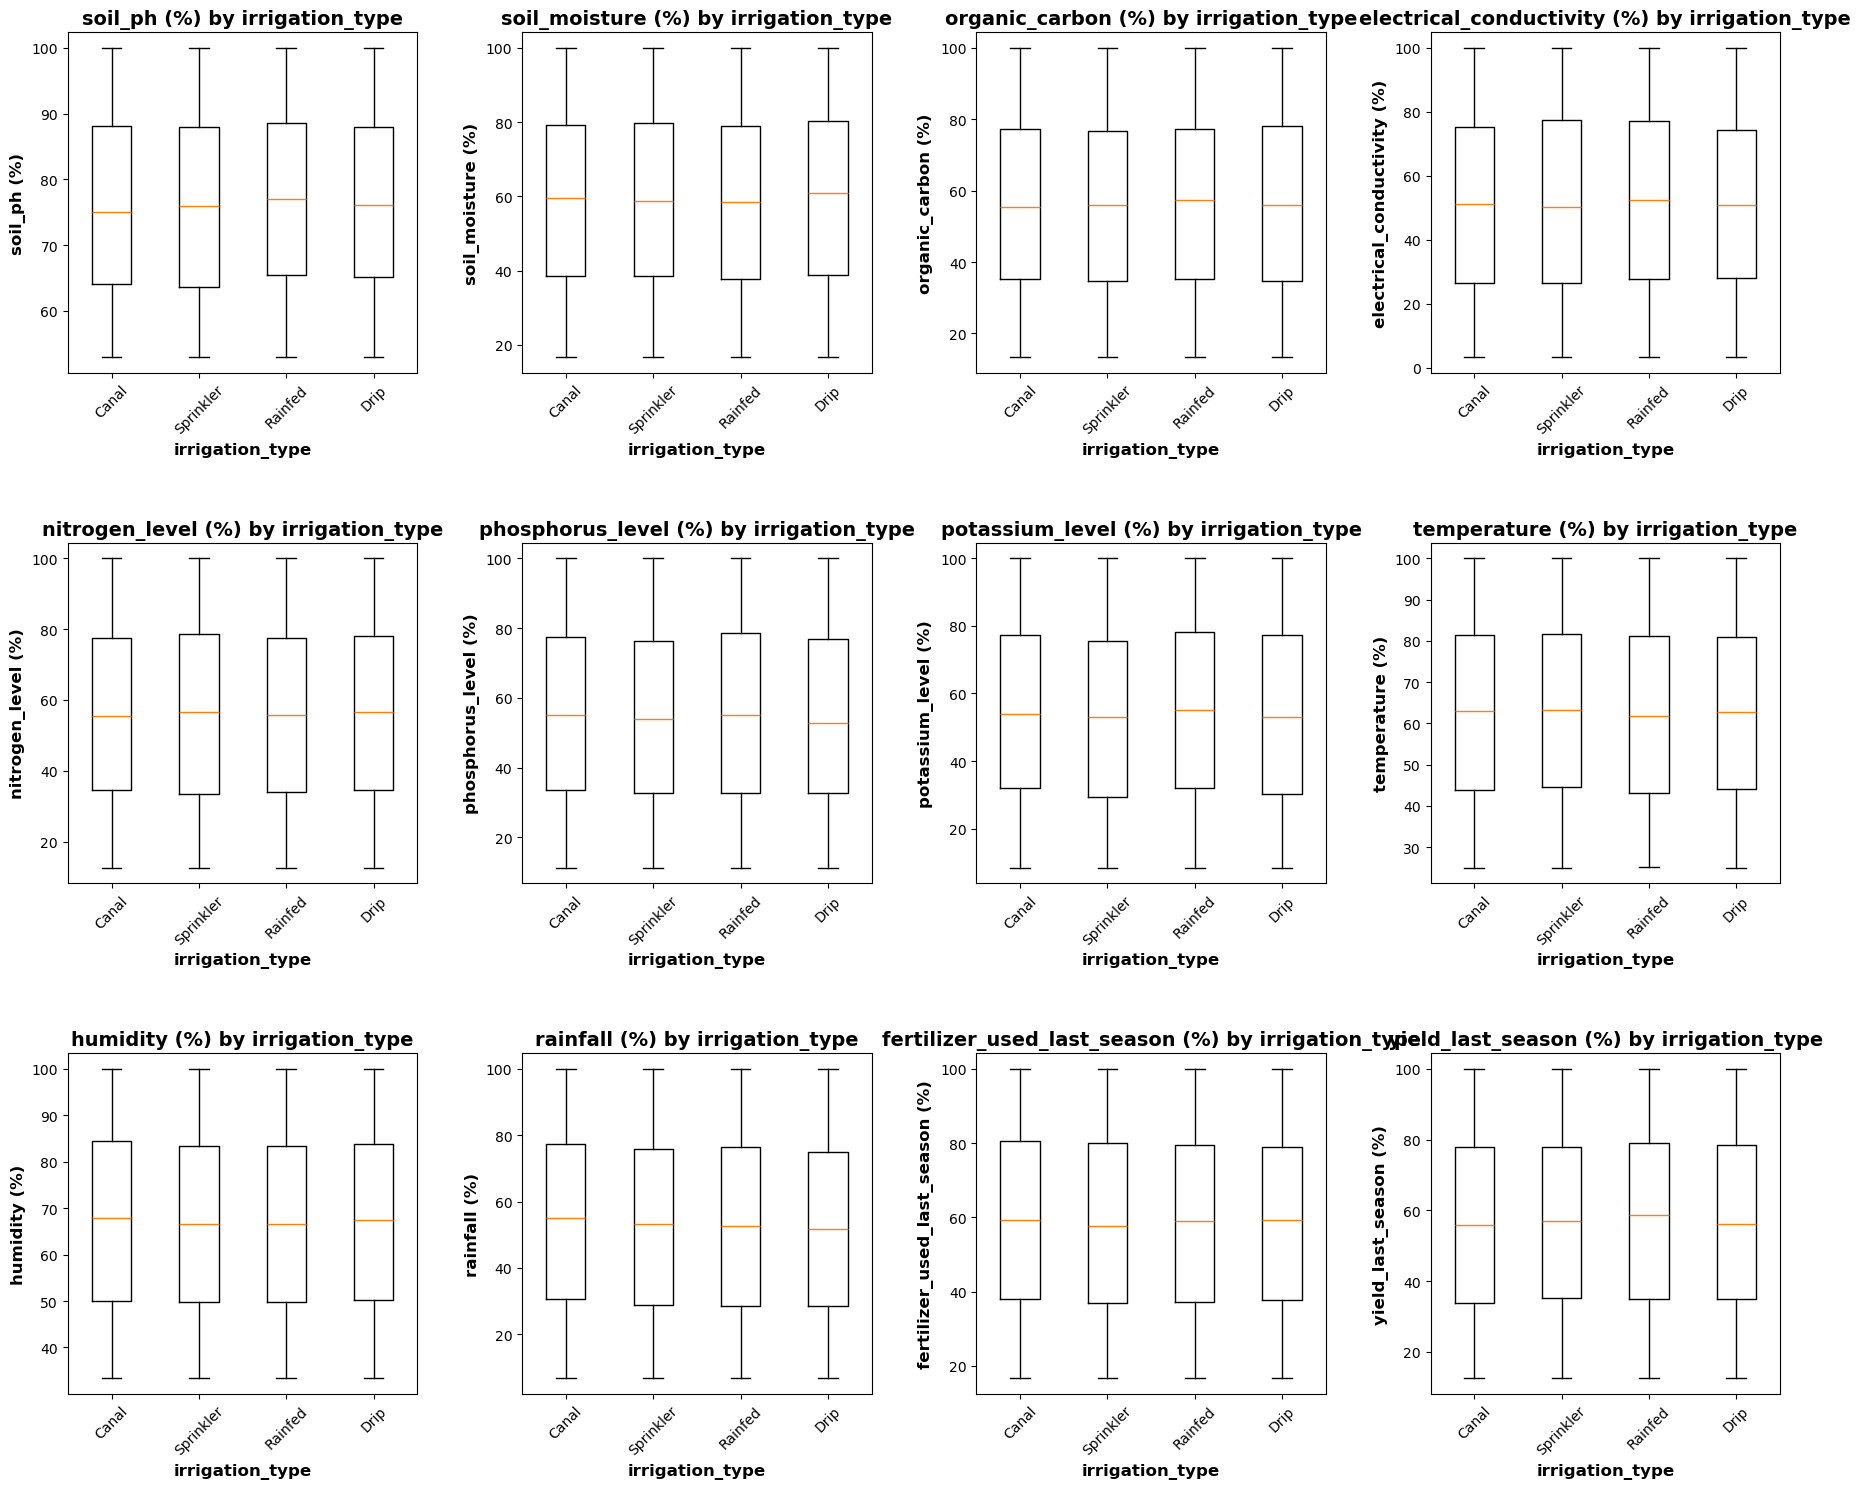

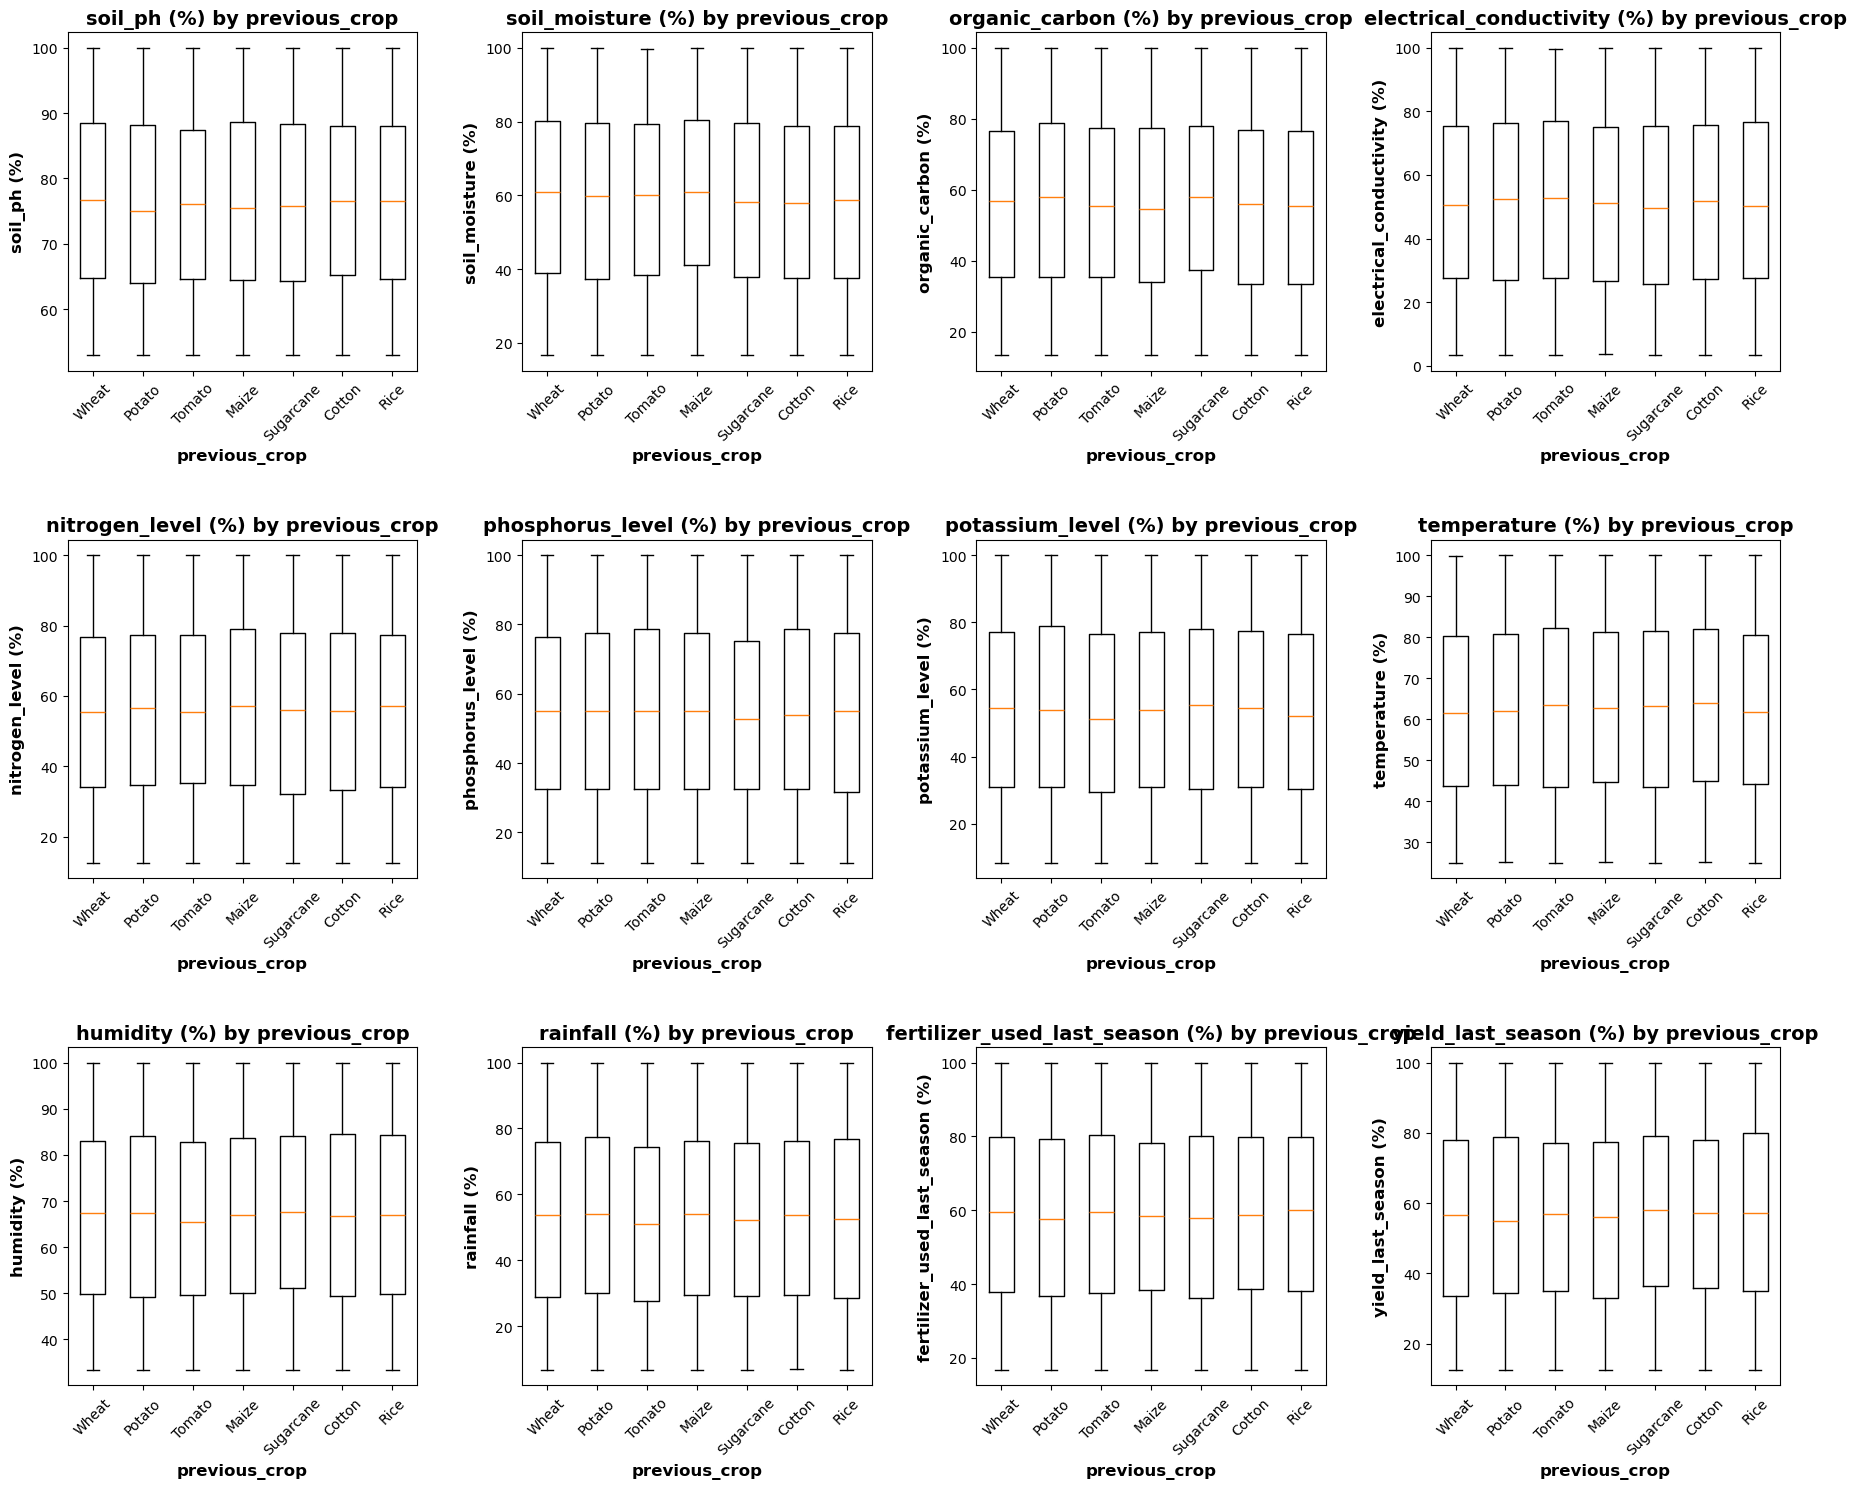

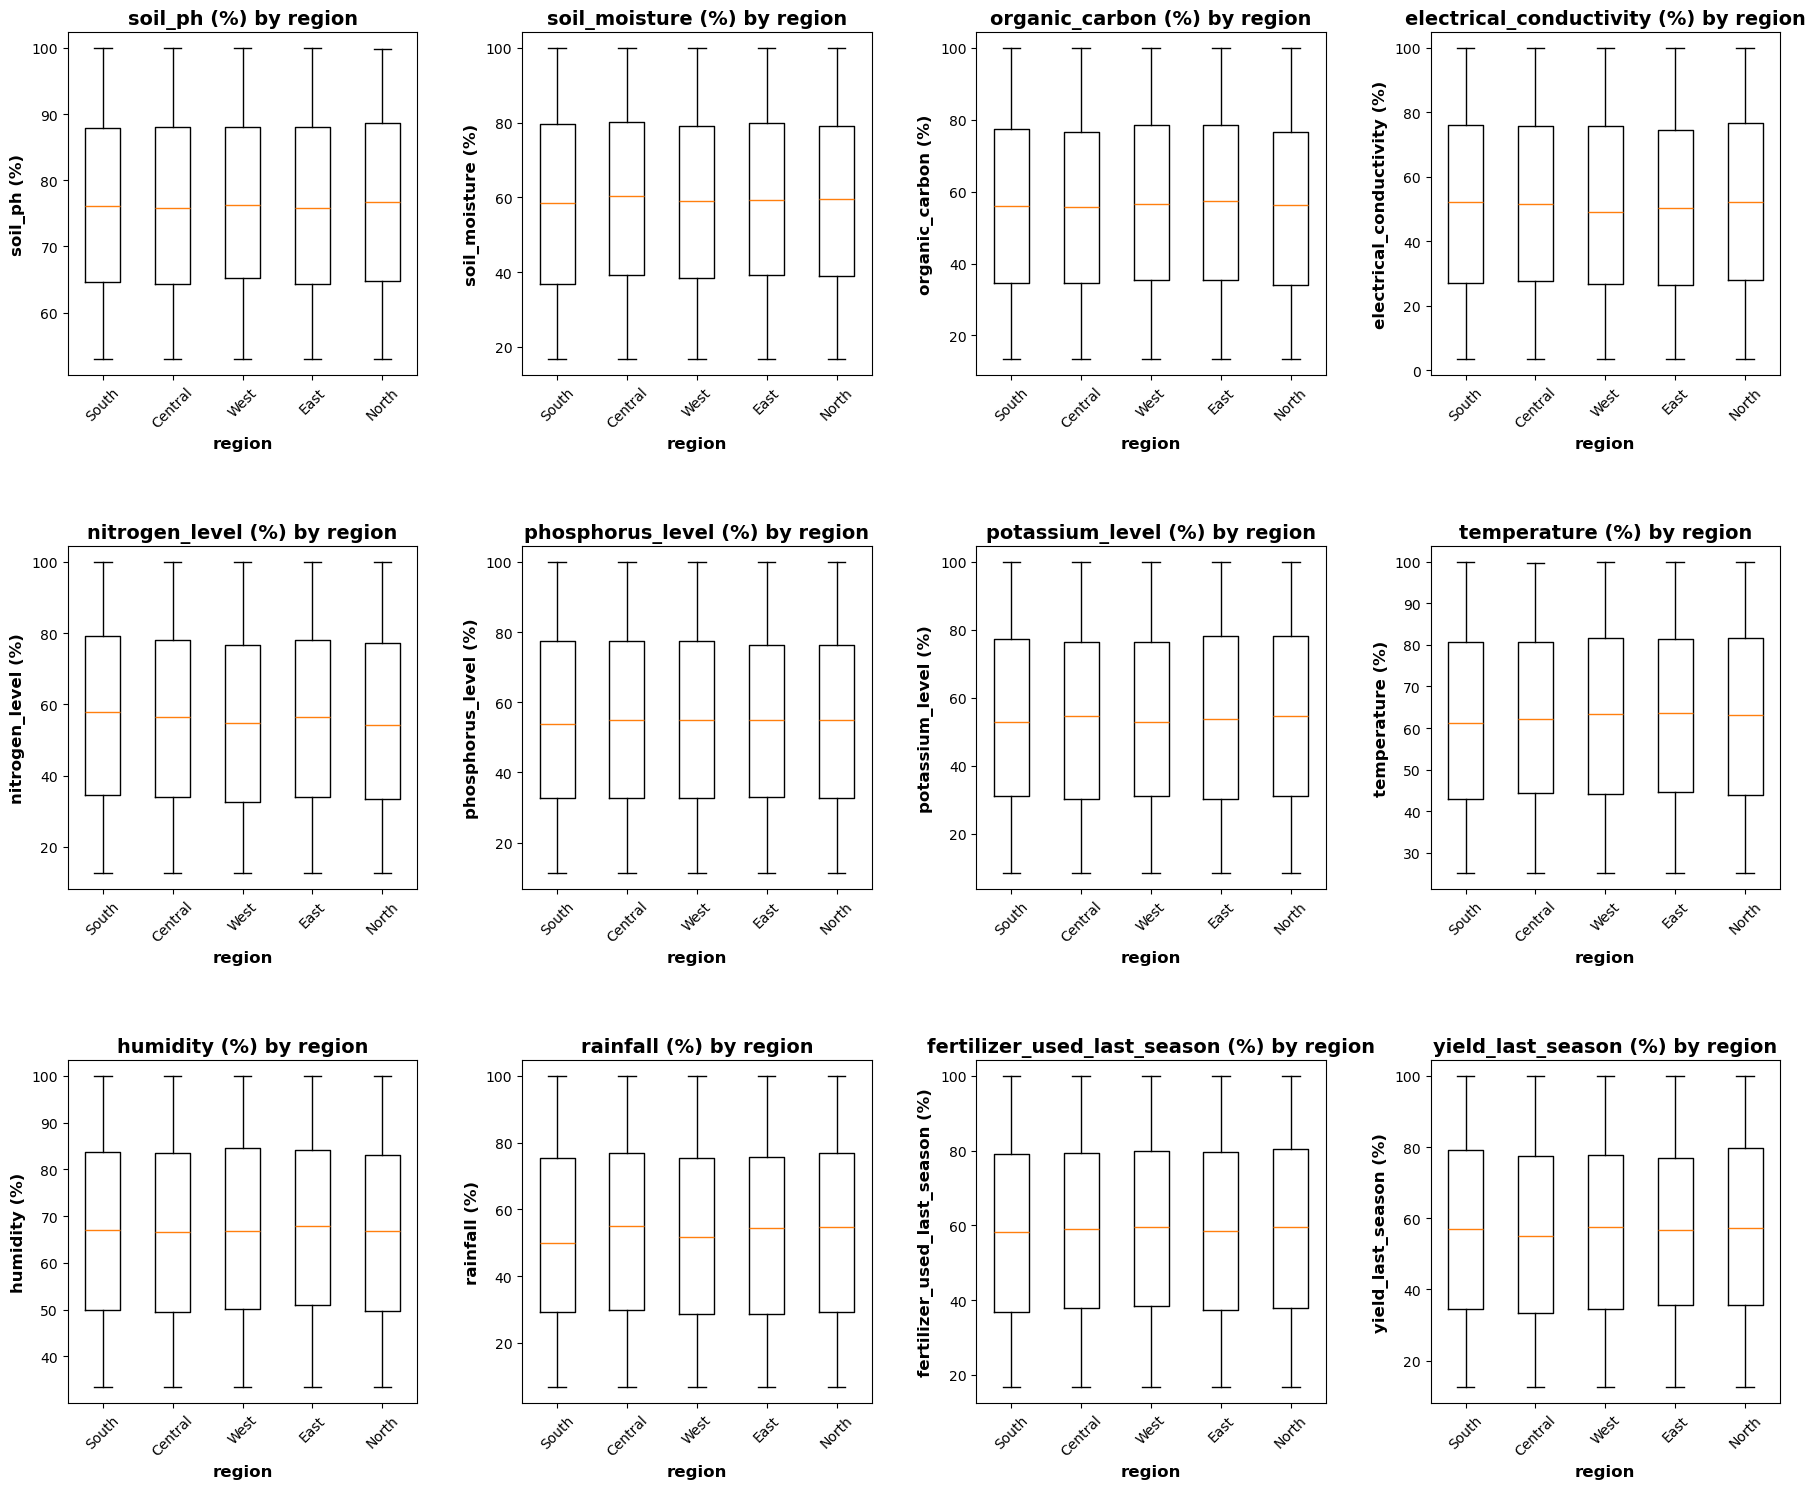

In [50]:
# Generate grouped boxplots for all categorical variables

for cat in categorical: 
    create_boxplot(df, cat, numerical)

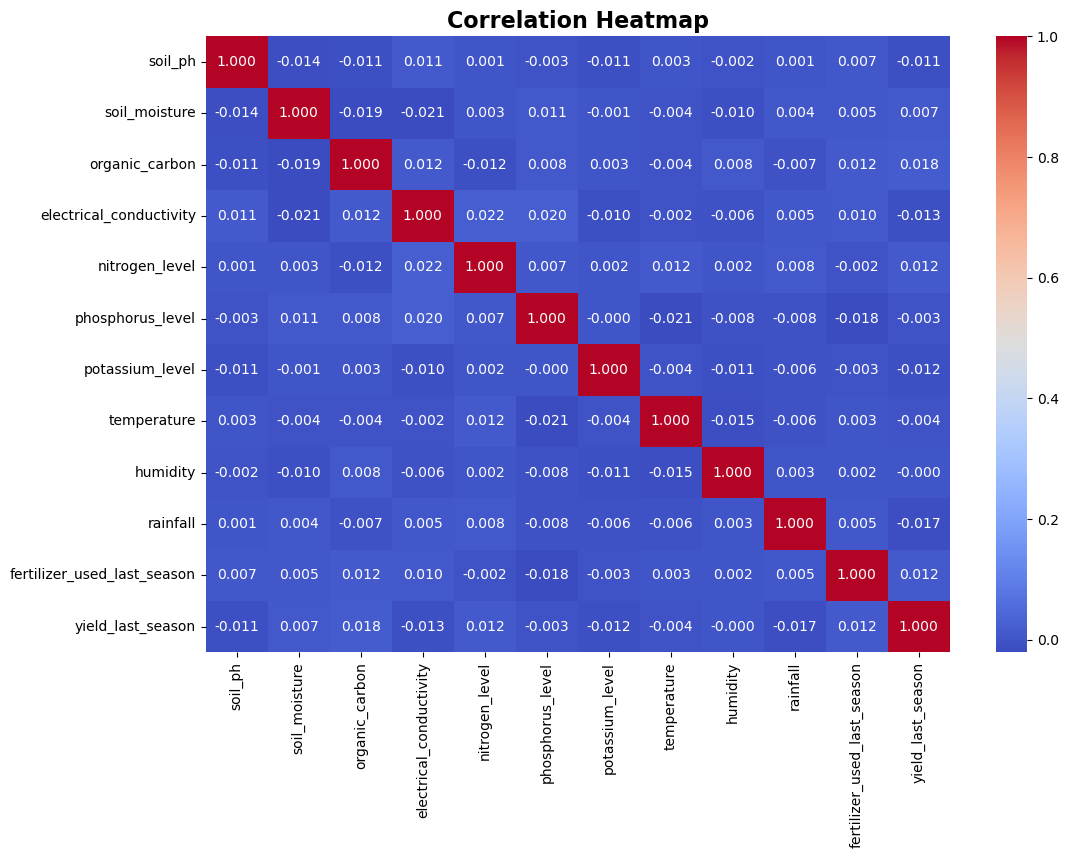

In [51]:
# Correlation heatmap for numerical features

corr = pd.DataFrame(df.corr(numeric_only=True, method="pearson"))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True,  cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.show()
